In [ ]:
!pip install pandas --upgrade
!pip install matplotlib --upgrade
!pip install seaborn --upgrade

^C


In [255]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# show full dataframe output in notebook
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)         # let pandas decide width
pd.set_option('display.max_colwidth', None)  # do not truncate column contents


In [269]:
# m = pd.read_csv("simulation_results/metrics_20250913_124425.csv")
# m4 = pd.read_csv("simulation_results/metrics_20251006_164807.csv") #mpeg4 - 4x4 - 500 cycles - 1s interval
# m4 = pd.read_csv("simulation_results/metrics_20251112_001135.csv")

# m4 = pd.read_csv("simulation_results/metrics_20251119_003436.csv") # mpeg4 - 4x4 - 100 bandwidth (30 steps até 150%) ok
# m4 = pd.read_csv("simulation_results/metrics_20251119_004702.csv") # mpeg4 - 4x4 - 100 bandwidth (30 steps até 200%)
# m4 = pd.read_csv("simulation_results/metrics_20251119_005708.csv") # mpeg4 - 4x4 - 100 bandwidth (50 steps até 150%)
# m4 = pd.read_csv("simulation_results/metrics_20251119_012315.csv")
# m8 = pd.read_csv("simulation_results/metrics_20251008_083904.csv") #mpeg4 - 8x8 - 500 cycles - 1s interval
# m4 = pd.read_csv("simulation_results/metrics_20251121_012544.csv") # mpeg4 - 4x4 - 100 bandwidth (50 steps até 150%) sequencial
# m4 = pd.read_csv("simulation_results/metrics_20251121_015511.csv") # mpeg4 - 4x4 - 100 bandwidth (100 steps até 130%) sequencial ok
# m4 = pd.read_csv("simulation_results/metrics_20251121_015858.csv") # mpeg4 - 4x4 - 8 bandwidth (10 steps até 100%) sequencial
# m4 = pd.read_csv("simulation_results/metrics_20251121_020055.csv") # mpeg4 - 4x4 - 8 bandwidth (30 steps até 50%) sequencial
m4 = pd.read_csv("simulation_results/metrics_20251124_003050.csv")
m8 = pd.read_csv("simulation_results/metrics_20251121_171134.csv")

## Network Throughput

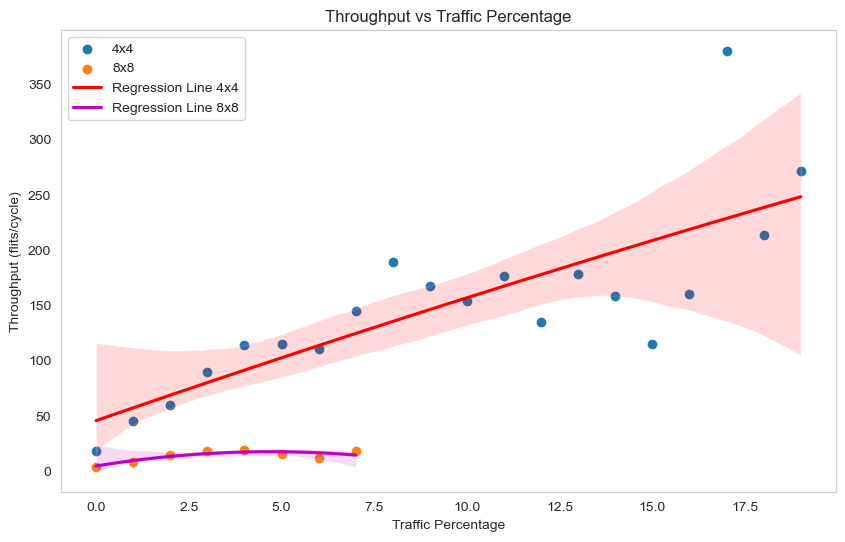

In [270]:
cycles_m4 = m4[m4['type'] == 'packet_arrived'].groupby('execution_id').max()['hops'].reset_index(name='cycles')
cycles_m8 = m8[m8['type'] == 'packet_arrived'].groupby('execution_id').max()['hops'].reset_index(name='cycles')
arrived_flit_m4 = m4[m4['type'] == 'packet_arrived'].groupby('execution_id').sum()['weight'].reset_index(name='arrived_flits')
arrived_flit_m8 = m8[m8['type'] == 'packet_arrived'].groupby('execution_id').sum()['weight'].reset_index(name='arrived_flits')

m4_stats = pd.merge(cycles_m4, arrived_flit_m4, on='execution_id')
m8_stats = pd.merge(cycles_m8, arrived_flit_m8, on='execution_id')
m4_stats['throughput'] = m4_stats['arrived_flits'] / m4_stats['cycles']
m8_stats['throughput'] = m8_stats['arrived_flits'] / m8_stats['cycles']

plt.figure(figsize=(10, 6))

plt.scatter(m4_stats.index, m4_stats['throughput'], marker='o', label='4x4')
plt.scatter(m8_stats.index, m8_stats['throughput'], marker='o', label='8x8')
# Regression line (order 1 = linear)
sns.regplot(x=m4_stats.index, y=m4_stats['throughput'], scatter=False, order=2, color='r', label='Regression Line 4x4')
sns.regplot(x=m8_stats.index, y=m8_stats['throughput'], scatter=False, order=2, color='m', label='Regression Line 8x8')
plt.title('Throughput vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Throughput (flits/cycle)')
plt.legend()
plt.grid()
plt.show()

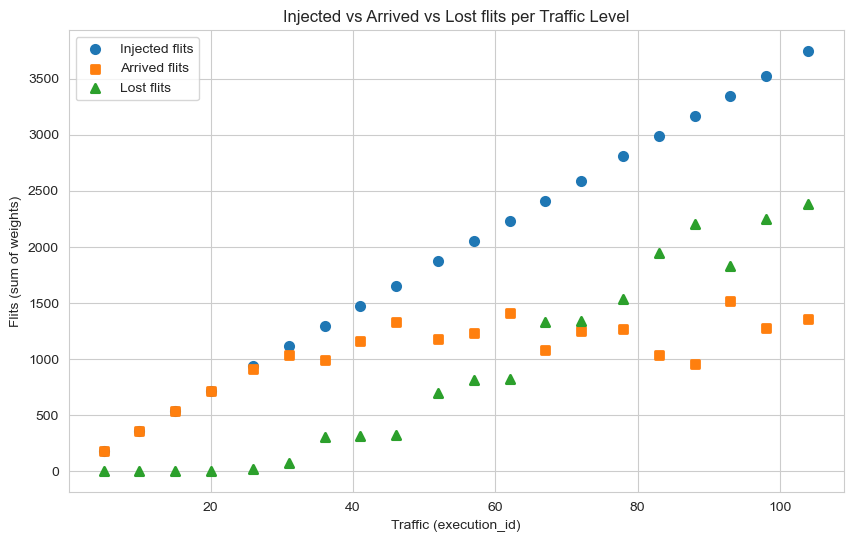

In [271]:
injected_flits = m4[m4['type'] == 'packet_sent'].groupby('execution_id').sum()['weight'].reset_index(name='injected_flits')
arrived_flit_m4 = m4[m4['type'] == 'packet_arrived'].groupby('execution_id').sum()['weight'].reset_index(name='arrived_flits')
lost_flits = m4[m4['type'] == 'packet_loss'].groupby('execution_id').sum()['weight'].reset_index(name='lost_flits')

stats_m4 = injected_flits.merge(arrived_flit_m4, on='execution_id', how='outer') \
                         .merge(lost_flits, on='execution_id', how='outer') \
                         .fillna(0)
stats_m4['total_flits'] = stats_m4['arrived_flits'] + stats_m4['lost_flits']
stats_m4[['injected_flits', 'total_flits', 'arrived_flits','lost_flits']] = stats_m4[['injected_flits','total_flits','arrived_flits','lost_flits']].astype(int)
stats_m4 = stats_m4.reindex(columns=['execution_id', 'injected_flits', 'total_flits', 'arrived_flits', 'lost_flits'])

# ensure numeric and sort by execution_id
for c in ['injected_flits', 'arrived_flits', 'lost_flits']:
    stats_m4[c] = pd.to_numeric(stats_m4[c], errors='coerce').fillna(0)
stats_m4 = stats_m4.sort_values('execution_id').reset_index(drop=True)

# plot three curves
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
plt.scatter(stats_m4['execution_id'], stats_m4['injected_flits'], marker='o', label='Injected flits', linewidth=2)
plt.scatter(stats_m4['execution_id'], stats_m4['arrived_flits'],  marker='s', label='Arrived flits',  linewidth=2)
plt.scatter(stats_m4['execution_id'], stats_m4['lost_flits'], marker='^', label='Lost flits',     linewidth=2)

plt.xlabel('Traffic (execution_id)')
plt.ylabel('Flits (sum of weights)')
plt.title('Injected vs Arrived vs Lost flits per Traffic Level')
plt.legend()
plt.grid(True)
plt.show()

## Average Latency

d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x

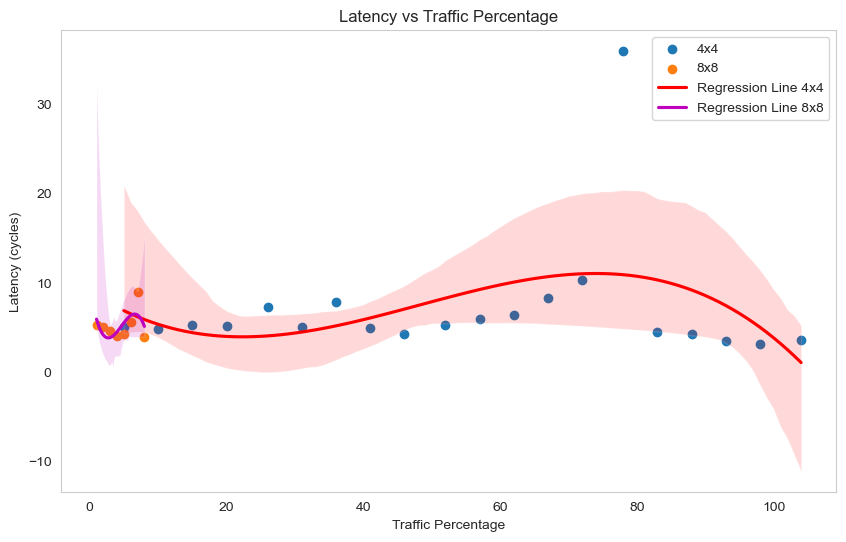

In [272]:
routed_flits_m4 = m4[m4['type'] == 'packet_routed'].groupby(['execution_id', 'packet_id']).sum()['weight'].reset_index(name='sum_flits')
routed_flits_m8 = m8[m8['type'] == 'packet_routed'].groupby(['execution_id', 'packet_id']).sum()['weight'].reset_index(name='sum_flits')
arrived_flits_m4 = m4[m4['type'] == 'packet_arrived'].groupby(['execution_id', 'packet_id']).sum()['weight'].reset_index(name='arrived_flits')
arrived_flits_m8 = m8[m8['type'] == 'packet_arrived'].groupby(['execution_id', 'packet_id']).sum()['weight'].reset_index(name='arrived_flits')

latency_m4 = pd.merge(routed_flits_m4, arrived_flits_m4, on=['execution_id','packet_id'])
latency_m8 = pd.merge(routed_flits_m8, arrived_flits_m8, on=['execution_id','packet_id'])

latency_m4['latency'] = latency_m4['sum_flits'] / latency_m4['arrived_flits']
latency_m8['latency'] = latency_m8['sum_flits'] / latency_m8['arrived_flits']
# Get the average latency
latency_m4['latency'] = latency_m4.groupby('execution_id').agg(
    mean_latency=('latency', 'mean')
)
latency_m8['latency'] = latency_m8.groupby('execution_id').agg(
    mean_latency=('latency', 'mean')
)

plt.figure(figsize=(10, 6))

plt.scatter(latency_m4.index, latency_m4['latency'], marker='o', label='4x4')
plt.scatter(latency_m8.index, latency_m8['latency'], marker='o', label='8x8')
# plt.scatter(throughput8.index, throughput8['throughput'], marker='o', label='8x8')
# Regression line (order 1 = linear)
sns.regplot(x=latency_m4.index, y=latency_m4['latency'], scatter=False, order=3, color='r', label='Regression Line 4x4')
sns.regplot(x=latency_m8.index, y=latency_m8['latency'], scatter=False, order=3, color='m', label='Regression Line 8x8')
# sns.regplot(x=throughput8.index, y=throughput8['throughput'], scatter=False, order=3, color='m', label='Regression Line 8x8')

plt.title('Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Latency (cycles)')
plt.legend()
plt.grid()
plt.show()

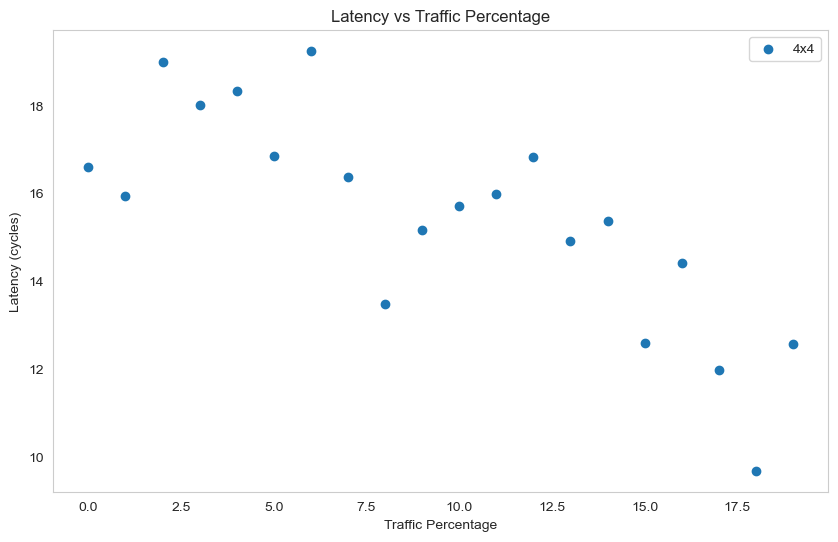

In [ ]:
df_arrived = m4[m4['type'] == 'packet_arrived'].copy()
df_sent = m4[m4['type'] == 'packet_sent'].copy()
df_lost = m4[m4['type'] == 'packet_loss'].copy()

diff_cycles_m4 = pd.merge(df_arrived, df_sent, on=["execution_id", "packet_id"], suffixes=('_arrived', '_sent'))

diff_cycles_m4['diff_cycles'] = pd.to_numeric(diff_cycles_m4['cycles_arrived'] - diff_cycles_m4['cycles_sent'], errors='coerce')

arrived_flits_m4 = df_arrived.groupby('execution_id').size().reset_index(name='arrived_flits')
lost_flits_m4 = df_lost.groupby('execution_id').size().reset_index(name='lost_flits')
latency_cycles_m4 = diff_cycles_m4.groupby('execution_id').sum()['diff_cycles'].reset_index(name='total_diff_cycles')

latency_cycles_m4 = pd.merge(latency_cycles_m4, arrived_flits_m4, on='execution_id')
latency_cycles_m4['latency'] = latency_cycles_m4['total_diff_cycles'] / latency_cycles_m4['arrived_flits']

# latency_cycles_m4 = diff_cycles.groupby('execution_id', as_index=False)['diff_cycles'] \
# 							  .mean() \
# 							  .rename(columns={'diff_cycles': 'latency_cycles'})

plt.figure(figsize=(10, 6))

plt.scatter(latency_cycles_m4.index, latency_cycles_m4['latency'], marker='o', label='4x4')
# plt.scatter(throughput8.index, throughput8['throughput'], marker='o', label='8x8')
# Regression line (order 1 = linear)
# sns.regplot(x=latency_m4.index, y=latency_m4['latency_ms'], scatter=False, order=3, color='r', label='Regression Line 4x4')
# sns.regplot(x=throughput8.index, y=throughput8['throughput'], scatter=False, order=3, color='m', label='Regression Line 8x8')

plt.title('Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Latency (cycles)')
plt.legend()
plt.grid()
plt.show()

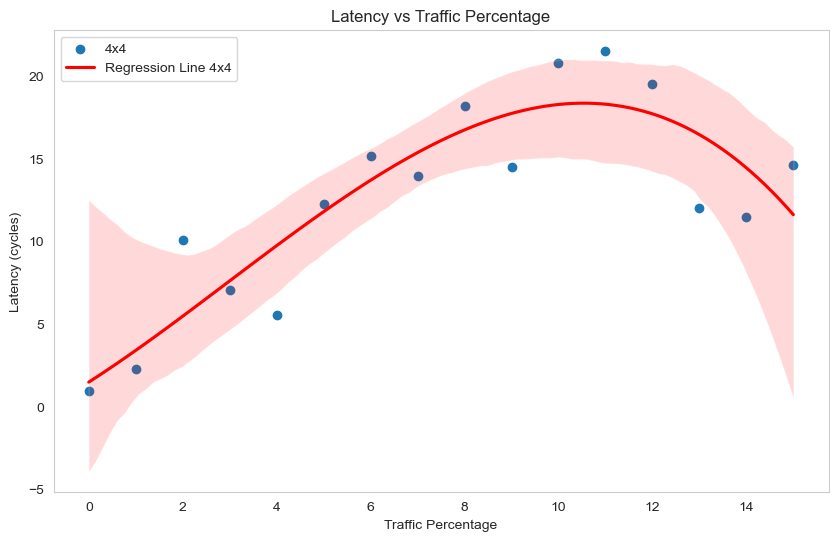

In [310]:
df_arrived = m4[m4['type'] == 'packet_arrived'].copy()
df_sent = m4[m4['type'] == 'packet_sent'].copy()
df_lost = m4[m4['type'] == 'packet_loss'].copy()
num_cycles = m4[m4['type'] == 'simulation_finished'].groupby('execution_id').max()['weight'].reset_index(name='num_cycles')

loss_rate_m4 = pd.merge(df_lost.groupby('execution_id').sum()['weight'].reset_index(name='lost_flits'),
                        df_sent.groupby('execution_id').sum()['weight'].reset_index(name='sent_flits'),
                        on='execution_id')
loss_rate_m4['loss_rate'] = loss_rate_m4['lost_flits'] / loss_rate_m4['sent_flits']

diff_cycles_m4 = pd.merge(df_arrived, df_sent, on=["execution_id", "packet_id"], suffixes=('_arrived', '_sent'))
diff_cycles_m4['diff_cycles'] = pd.to_numeric(diff_cycles_m4['cycles_arrived'] - diff_cycles_m4['cycles_sent'], errors='coerce')
arrived_flits_m4 = df_arrived.groupby('execution_id').size().reset_index(name='arrived_flits')
latency_cycles_m4 = diff_cycles_m4.groupby('execution_id').sum()['diff_cycles'].reset_index(name='total_diff_cycles')
latency_cycles_m4 = pd.merge(latency_cycles_m4, arrived_flits_m4, on='execution_id')
latency_cycles_m4['latency'] = latency_cycles_m4['total_diff_cycles'] / latency_cycles_m4['arrived_flits']

weighted_latency_m4 = pd.merge(loss_rate_m4, latency_cycles_m4[['execution_id', 'latency']], on='execution_id')
weighted_latency_m4 = pd.merge(weighted_latency_m4, num_cycles, on='execution_id')
weighted_latency_m4['effective_latency'] = (weighted_latency_m4['latency'] + (weighted_latency_m4['lost_flits'] * weighted_latency_m4['num_cycles'])) / weighted_latency_m4['sent_flits']
weighted_latency_m4
plt.figure(figsize=(10, 6))

plt.scatter(weighted_latency_m4.index, weighted_latency_m4['effective_latency'], marker='o', label='4x4')
# plt.scatter(throughput8.index, throughput8['throughput'], marker='o', label='8x8')
# Regression line (order 1 = linear)
sns.regplot(x=weighted_latency_m4.index, y=weighted_latency_m4['effective_latency'], scatter=False, order=3, color='r', label='Regression Line 4x4')
# sns.regplot(x=throughput8.index, y=throughput8['throughput'], scatter=False, order=3, color='m', label='Regression Line 8x8')

plt.title('Latency vs Traffic Percentage')
plt.xlabel('Traffic Percentage')
plt.ylabel('Latency (cycles)')
plt.legend()
plt.grid()
plt.show()

In [299]:
m4[m4['type'] == 'simulation_finished']

,source,id,type,timestamp,packet_id,src,dst,hops,cycles,from_dir,to_dir,creation_time,deliver_time,execution_id,weight
253,simulation,NaN,simulation_finished,2025-11-24 00:30:51.029169,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,5,38
499,simulation,NaN,simulation_finished,2025-11-24 00:30:51.217248,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,10,33
764,simulation,NaN,simulation_finished,2025-11-24 00:30:51.377318,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,15,43
1023,simulation,NaN,simulation_finished,2025-11-24 00:30:51.543078,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,20,38
1290,simulation,NaN,simulation_finished,2025-11-24 00:30:51.725254,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,26,38
1541,simulation,NaN,simulation_finished,2025-11-24 00:30:51.961161,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,31,33
1815,simulation,NaN,simulation_finished,2025-11-24 00:30:52.381845,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,36,43
2072,simulation,NaN,simulation_finished,2025-11-24 00:30:52.554264,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,41,33
2306,simulation,NaN,simulation_finished,2025-11-24 00:30:52.699496,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,46,28
2551,simulation,NaN,simulation_finished,2025-11-24 00:30:52.869350,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,52,33


In [ ]:
m4[m4['type'] == 'packet_arrived'].sort_values(by=['execution_id', 'packet_id'])

,source,id,type,timestamp,packet_id,src,dst,hops,cycles,from_dir,to_dir,creation_time,deliver_time,execution_id,weight
230,packet,1,packet_arrived,2025-11-24 00:30:50.988852,1.0,"(0, 0)","(5, 5)",10,21,NaN,NaN,2025-11-24 00:30:50.600568,2025-11-24 00:30:50.988852,5,5
197,packet,2,packet_arrived,2025-11-24 00:30:50.954384,2.0,"(0, 1)","(4, 3)",6,16,NaN,NaN,2025-11-24 00:30:50.601635,2025-11-24 00:30:50.954384,5,5
155,packet,3,packet_arrived,2025-11-24 00:30:50.907423,3.0,"(0, 2)","(0, 0)",2,12,NaN,NaN,2025-11-24 00:30:50.602162,2025-11-24 00:30:50.907423,5,5
226,packet,4,packet_arrived,2025-11-24 00:30:50.986237,4.0,"(0, 3)","(2, 0)",5,21,NaN,NaN,2025-11-24 00:30:50.604696,2025-11-24 00:30:50.986237,5,5
156,packet,5,packet_arrived,2025-11-24 00:30:50.909496,5.0,"(0, 4)","(0, 2)",2,12,NaN,NaN,2025-11-24 00:30:50.606525,2025-11-24 00:30:50.909496,5,5
227,packet,6,packet_arrived,2025-11-24 00:30:50.986237,6.0,"(0, 5)","(2, 3)",4,21,NaN,NaN,2025-11-24 00:30:50.607644,2025-11-24 00:30:50.986237,5,5
199,packet,7,packet_arrived,2025-11-24 00:30:50.956017,7.0,"(1, 0)","(5, 5)",9,16,NaN,NaN,2025-11-24 00:30:50.608740,2025-11-24 00:30:50.956017,5,5
102,packet,8,packet_arrived,2025-11-24 00:30:50.754623,8.0,"(1, 1)","(0, 1)",1,8,NaN,NaN,2025-11-24 00:30:50.608740,2025-11-24 00:30:50.754623,5,5
142,packet,9,packet_arrived,2025-11-24 00:30:50.878709,9.0,"(1, 2)","(5, 3)",5,11,NaN,NaN,2025-11-24 00:30:50.611359,2025-11-24 00:30:50.878709,5,5
127,packet,10,packet_arrived,2025-11-24 00:30:50.770294,10.0,"(1, 3)","(1, 5)",2,9,NaN,NaN,2025-11-24 00:30:50.612587,2025-11-24 00:30:50.770294,5,5


In [ ]:
m4[m4['type'] == 'packet_arrived']

,source,id,type,timestamp,packet_id,src,dst,hops,from_dir,to_dir,creation_time,deliver_time,execution_id,weight
124,packet,43,packet_arrived,2025-11-21 17:11:34.399595,43.0,"(1, 0)","(3, 0)",2,NaN,NaN,2025-11-21 17:11:34.340513,2025-11-21 17:11:34.399595,1,1
125,packet,38,packet_arrived,2025-11-21 17:11:34.401471,38.0,"(0, 1)","(5, 1)",5,NaN,NaN,2025-11-21 17:11:34.334404,2025-11-21 17:11:34.401471,1,1
126,packet,64,packet_arrived,2025-11-21 17:11:34.403843,64.0,"(4, 3)","(5, 3)",1,NaN,NaN,2025-11-21 17:11:34.356528,2025-11-21 17:11:34.402825,1,1
127,packet,48,packet_arrived,2025-11-21 17:11:34.403843,48.0,"(1, 5)","(5, 5)",4,NaN,NaN,2025-11-21 17:11:34.345286,2025-11-21 17:11:34.403843,1,1
145,packet,47,packet_arrived,2025-11-21 17:11:34.427177,47.0,"(1, 4)","(0, 4)",1,NaN,NaN,2025-11-21 17:11:34.344759,2025-11-21 17:11:34.427177,1,1
185,packet,40,packet_arrived,2025-11-21 17:11:34.455550,40.0,"(0, 3)","(1, 2)",2,NaN,NaN,2025-11-21 17:11:34.338131,2025-11-21 17:11:34.455550,1,1
186,packet,50,packet_arrived,2025-11-21 17:11:34.456240,50.0,"(2, 1)","(4, 0)",3,NaN,NaN,2025-11-21 17:11:34.346303,2025-11-21 17:11:34.456240,1,1
187,packet,39,packet_arrived,2025-11-21 17:11:34.457286,39.0,"(0, 2)","(4, 1)",5,NaN,NaN,2025-11-21 17:11:34.337104,2025-11-21 17:11:34.457286,1,1
188,packet,49,packet_arrived,2025-11-21 17:11:34.462407,49.0,"(2, 0)","(4, 2)",4,NaN,NaN,2025-11-21 17:11:34.346303,2025-11-21 17:11:34.462295,1,1
189,packet,46,packet_arrived,2025-11-21 17:11:34.463480,46.0,"(1, 3)","(5, 3)",4,NaN,NaN,2025-11-21 17:11:34.343133,2025-11-21 17:11:34.463480,1,1


## Packet Loss

d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)


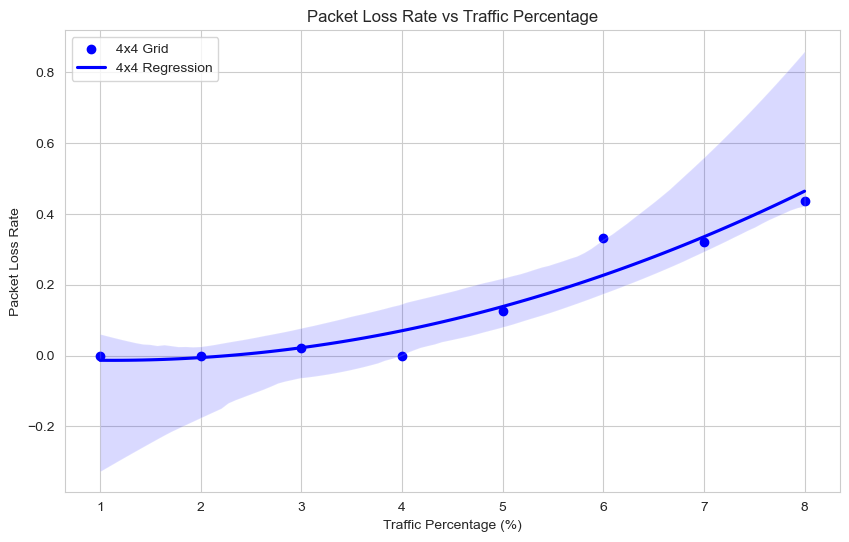

In [243]:
# Get the total packets lost per traffic level
injected_flits = m4[m4['type'] == 'packet_sent'].groupby('execution_id').sum()['weight'].reset_index(name='injected_flits')
lost_flits = m4[m4['type'] == 'packet_loss'].groupby('execution_id').sum()['weight'].reset_index(name='lost_flits')
# total_lost8 = loss8.groupby('execution_id').size().reset_index(name='total_lost')
# Merge the two dataframes
loss_stats4 = pd.merge(injected_flits, lost_flits, on='execution_id', how='left').fillna(0)
# loss_stats8 = pd.merge(total_sent8, total_lost8, on='execution_id', how='left').fillna(0)
# Calculate loss rate
loss_stats4['loss_rate'] = loss_stats4['lost_flits'] / loss_stats4['injected_flits']
# loss_stats8['loss_rate'] = loss_stats8['total_lost'] / loss_stats8['total_sent'] 

plt.figure(figsize=(10, 6))

# Plot only points for both grids
plt.scatter(loss_stats4['execution_id'], loss_stats4['loss_rate'], color='b', label='4x4 Grid')
# plt.scatter(loss_stats8['execution_id'], loss_stats8['loss_rate'], color='g', label='8x8 Grid')

# Regression lines for both grids
sns.regplot(x=loss_stats4['execution_id'], y=loss_stats4['loss_rate'], scatter=False, order=2, color='b', label='4x4 Regression')
# sns.regplot(x=loss_stats8['execution_id'], y=loss_stats8['loss_rate'], scatter=False, order=3, color='g', label='8x8 Regression')

plt.title('Packet Loss Rate vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Packet Loss Rate')
plt.grid(True)
plt.legend()
plt.show()

In [206]:
# Filter for packet_arrived
arrived4 = m4[m4['type'] == 'packet_arrived'].copy()
# arrived8 = m8[m8['type'] == 'packet_arrived'].copy()
# Filter for packet_loss
loss4 = m4[m4['type'] == 'packet_loss'].copy()
# loss8 = m8[m8['type'] == 'packet_loss'].copy()
# Get the total packets sent per traffic level
total_sent4 = m4[m4['type'] == 'packet_sent'].groupby('execution_id').size().reset_index(name='total_sent')
# total_sent8 = m8[m8['type'] == 'packet_sent'].groupby('execution_id').size().reset_index(name='total_sent')
# Convert to datetime if not already
arrived4['creation_time'] = pd.to_datetime(arrived4['creation_time'])
arrived4['deliver_time'] = pd.to_datetime(arrived4['deliver_time'])
# arrived8['creation_time'] = pd.to_datetime(arrived8['creation_time'])
# arrived8['deliver_time'] = pd.to_datetime(arrived8['deliver_time'])
# Calculate latency in seconds
arrived4['latency_sec'] = (arrived4['deliver_time'] - arrived4['creation_time']).dt.total_seconds()
# arrived8['latency_sec'] = (arrived8['deliver_time'] - arrived8['creation_time']).dt.total_seconds()

In [207]:
simulation_time4 = arrived4.groupby('execution_id').agg({'creation_time': 'min', 'deliver_time': 'max'})
# simulation_time8 = arrived8.groupby('execution_id').agg({'creation_time': 'min', 'deliver_time': 'max'})
# Calculate total simulation time in seconds
simulation_time4['duration_sec'] = (simulation_time4['deliver_time'] - simulation_time4['creation_time']).dt.total_seconds()
# simulation_time8['duration_sec'] = (simulation_time8['deliver_time'] - simulation_time8['creation_time']).dt.total_seconds()

In [191]:
throughput4 = arrived4.copy()
total_loss = loss4.groupby('execution_id').agg(total_loss=('weight', 'sum')).reset_index()
# use named aggregation to produce the desired column name, then reset the index
total_arrived = throughput4.groupby('execution_id').agg(total_arrived=('weight', 'sum')).reset_index()

## Node Throughput

## Extra Delay

C:\Users\igorf\AppData\Local\Temp\ipykernel_7064\2564310102.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  extra_delay4 = pd.merge(arrived4, min_latency4, on='execution_id', how='left').fillna(0)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
d:\Projects\MCTOR\.conda\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)


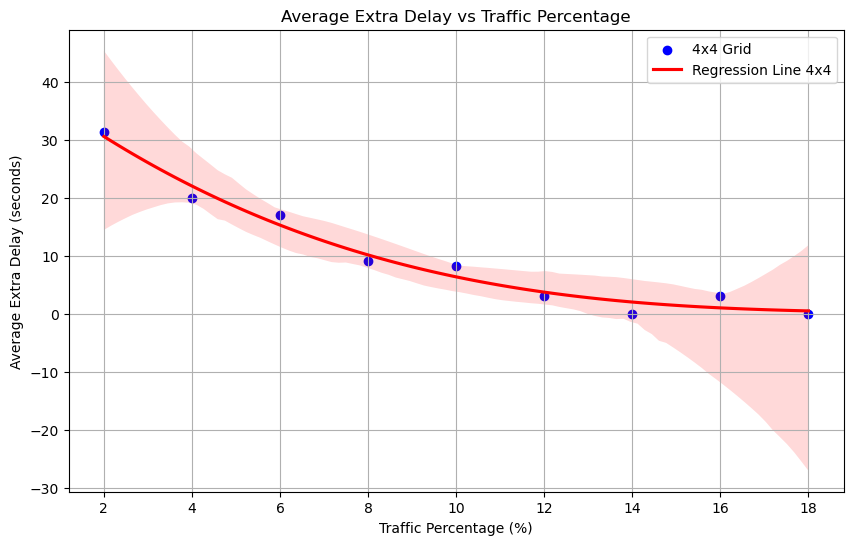

In [9]:
# Get the minimum latency
min_latency4 = latency4['latency_sec']['min'].reset_index(name='min_latency')
# min_latency8 = latency8['latency_sec']['min'].reset_index(name='min_latency')
# Calculate the extra delay by subtracting the minimum latency from the average latency
extra_delay4 = pd.merge(arrived4, min_latency4, on='execution_id', how='left').fillna(0)
# extra_delay8 = pd.merge(arrived8, min_latency8, on='execution_id', how='left').fillna(0)
extra_delay4['extra_delay_sec'] = extra_delay4['latency_sec'] - extra_delay4['min_latency']
# extra_delay8['extra_delay_sec'] = extra_delay8['latency_sec'] - extra_delay8['min_latency']
# Plot the extra delay
extra_delay_summary4 = extra_delay4.groupby('execution_id').agg({'extra_delay_sec': ['mean', 'std', 'min', 'max']})
# extra_delay_summary8 = extra_delay8.groupby('execution_id').agg({'extra_delay_sec': ['mean', 'std', 'min', 'max']})

plt.figure(figsize=(10, 6))

# Plot only points for both grids
plt.scatter(extra_delay_summary4.index, extra_delay_summary4['extra_delay_sec']['mean'], color='b', label='4x4 Grid')
# plt.scatter(extra_delay_summary8.index, extra_delay_summary8['extra_delay_sec']['mean'], color='g', label='8x8 Grid')

# Regression line (order 1 = linear)
sns.regplot(x=extra_delay_summary4.index, y=extra_delay_summary4['extra_delay_sec']['mean'], scatter=False, order=3, color='r', label='Regression Line 4x4')
# sns.regplot(x=extra_delay_summary8.index, y=extra_delay_summary8['extra_delay_sec']['mean'], scatter=False, order=3, color='m', label='Regression Line 8x8')

plt.title('Average Extra Delay vs Traffic Percentage')
plt.xlabel('Traffic Percentage (%)')
plt.ylabel('Average Extra Delay (seconds)')
plt.grid(True)
plt.legend()
plt.show()